# Energy Forecasting — Baselines, SARIMA/SARIMAX, LSTM, N-BEATS and Hybrid Residual NN
## v6 — Fixed for `avg_kwh_per_user` target

**What changed vs v5 (`5_forecasting_models.ipynb`):**
- **TARGET = `avg_kwh_per_user`**: lag/rolling/zscore/pct_rank features now computed on the actual target series, not on `avg_kwh`
- **`n_users_lag1d`, `n_users_roll7` added**: active users drive the denominator; known at forecast time
- **`avg_kwh_lag1d` added**: total municipality consumption (lagged 1 day) as exogenous covariate
- **Hybrid residual fix**: test loop uses zero-padding instead of autoregressive residual feedback, preventing compounding errors on the small per-user scale

In [1]:
# 0. Imports and config
import warnings, random, gc, math
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# Turn off while testing if it is too heavy
RUN_SARIMA = True
RUN_SARIMAX = True
RUN_LSTM = True
RUN_NBEATS = True
RUN_HYBRID = True

EPOCHS = 80
BATCH_SIZE = 64
PATIENCE = 15
SEQ_LENGTH = 30
FORECAST_SEASONAL_PERIOD = 365  # diário: 7 semanal; muda para 365 para yearly seasonal naive
SARIMA_SEASONAL_PERIOD = 7     # 365 fica muito pesado em SARIMA/SARIMAX

Device: cpu


## 1. Load data

Altera `DATA_PATH` para o teu CSV. O notebook tenta detetar automaticamente:
- target: `kwh_per_user`, `avg_kwh`, `kWh`, `kwh`
- grupo: `municipality`, `_source_folder`, `user_id`, `id`


In [ ]:
BASE_PATH = Path(r'C:/Users/GONCA/Desktop/Iscte/MCD/Theses')
DATA_PATH = BASE_PATH / 'results' / 'data' / 'municipality_daily_consumption.csv'

DATE_COL = 'date'
# v6: avg_kwh_per_user is now the primary target so all lags/rollings are computed on it
TARGET_CANDIDATES = ['avg_kwh']
GROUP_CANDIDATES = ['municipality', '_source_folder', 'user_id', 'id']

def pick_first_existing(columns, candidates, label):
    for c in candidates:
        if c in columns:
            return c
    raise ValueError(f'Could not find {label}. Tried: {candidates}')

df_raw = pd.read_csv(DATA_PATH)
df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL])
df_raw = df_raw.sort_values(DATE_COL).reset_index(drop=True)

# Compute per-user energy density if not already present
if 'avg_kwh_per_user' not in df_raw.columns:
    df_raw['avg_kwh_per_user'] = df_raw['avg_kwh'] / df_raw['n_users'].replace(0, float('nan'))

TARGET_COL = pick_first_existing(df_raw.columns, TARGET_CANDIDATES, 'target column')
GROUP_COL = pick_first_existing(df_raw.columns, GROUP_CANDIDATES, 'group column')

print('Shape:', df_raw.shape)
print('Date range:', df_raw[DATE_COL].min().date(), '→', df_raw[DATE_COL].max().date())
print('Target:', TARGET_COL)
print('Group:', GROUP_COL)
display(df_raw.head())

Shape: (115144, 6)
Date range: 2014-11-04 → 2022-06-08
Target: avg_kwh_per_user
Group: municipality


,municipality,date,avg_kwh,std_kwh,n_users,avg_kwh_per_user
0,Santander,2014-11-04,0.138348,0.155339,3,0.046116
1,Santander,2014-11-05,0.218616,0.202234,4,0.054654
2,Santander,2014-11-06,0.184656,0.145579,4,0.046164
3,Santander,2014-11-07,0.198615,0.154671,4,0.049654
4,Santander,2014-11-08,0.152052,0.135469,4,0.038013


## 2. Feature engineering

Se as colunas já existirem, são mantidas. Se faltarem, são criadas quando possível.

In [3]:
FEATURE_COLUMNS_REQUESTED = [
    'is_weekend', 'day_of_week', 'month', 'quarter', 'week_of_year',
    'is_holiday_pt', 'is_bridge_day',
    'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d',
    'roll7_mean', 'roll7_std', 'roll30_mean', 'roll7_ratio',
    'wow_change', 'dod_change',
    'zscore_municipality', 'pct_rank_global',
    # v6: n_users features (denominator of avg_kwh_per_user, known at forecast time)
    'n_users_lag1d', 'n_users_roll7',
    # v6: total municipality consumption lagged (exogenous covariate)
    'avg_kwh_lag1d',
]

def add_calendar_features(df):
    df = df.copy()
    df['day_of_week']  = df[DATE_COL].dt.dayofweek
    df['day_name']     = df[DATE_COL].dt.day_name()
    df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)
    df['month']        = df[DATE_COL].dt.month
    df['month_name']   = df[DATE_COL].dt.month_name()
    df['quarter']      = df[DATE_COL].dt.quarter
    df['week_of_year'] = df[DATE_COL].dt.isocalendar().week.astype(int)
    df['sin_dow']   = np.sin(2 * np.pi * df['day_of_week']  / 7)
    df['cos_dow']   = np.cos(2 * np.pi * df['day_of_week']  / 7)
    df['sin_month'] = np.sin(2 * np.pi * df['month']        / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month']        / 12)
    df['sin_week']  = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['cos_week']  = np.cos(2 * np.pi * df['week_of_year'] / 52)
    return df

def add_pt_holidays(df):
    df = df.copy()
    try:
        import holidays
        years = sorted(df[DATE_COL].dt.year.unique())
        pt_holidays = holidays.country_holidays('PT', years=years)
        holiday_dates = set(pd.to_datetime(list(pt_holidays.keys())))
        df['is_holiday_pt'] = df[DATE_COL].isin(holiday_dates).astype(int)
        next_day = df[DATE_COL] + pd.Timedelta(days=1)
        prev_day = df[DATE_COL] - pd.Timedelta(days=1)
        df['is_bridge_day'] = (
            ((df[DATE_COL].dt.dayofweek == 0) & next_day.isin(holiday_dates)) |
            ((df[DATE_COL].dt.dayofweek == 4) & prev_day.isin(holiday_dates))
        ).astype(int)
    except Exception:
        df['is_holiday_pt'] = df.get('is_holiday_pt', 0)
        df['is_bridge_day'] = df.get('is_bridge_day', 0)
    return df

def add_lags_rollings(df, target_col, group_col):
    # All lags/rollings are computed on target_col (avg_kwh_per_user in v6)
    df = df.sort_values([group_col, DATE_COL]).copy()
    g  = df.groupby(group_col, group_keys=False)[target_col]
    for lag in [1, 7, 14, 30]:
        col = f'lag_{lag}d'
        if col not in df.columns:
            df[col] = g.shift(lag)
    if 'roll7_mean'  not in df.columns: df['roll7_mean']  = g.shift(1).rolling(7,  min_periods=1).mean().reset_index(level=0, drop=True)
    if 'roll7_std'   not in df.columns: df['roll7_std']   = g.shift(1).rolling(7,  min_periods=2).std().reset_index(level=0, drop=True)
    if 'roll30_mean' not in df.columns: df['roll30_mean'] = g.shift(1).rolling(30, min_periods=1).mean().reset_index(level=0, drop=True)
    if 'roll7_ratio' not in df.columns: df['roll7_ratio'] = df['lag_1d'] / df['roll7_mean'].replace(0, np.nan)
    if 'wow_change'  not in df.columns: df['wow_change']  = (df['lag_1d'] - df['lag_7d'])   / df['lag_7d'].replace(0, np.nan)
    if 'dod_change'  not in df.columns:
        lag_2d = g.shift(2)
        df['dod_change'] = (df['lag_1d'] - lag_2d) / lag_2d.replace(0, np.nan)
    if 'zscore_municipality' not in df.columns:
        exp_mean = g.expanding(min_periods=30).mean().shift(1).reset_index(level=0, drop=True)
        exp_std  = g.expanding(min_periods=30).std().shift(1).reset_index(level=0, drop=True)
        df['zscore_municipality'] = (df[target_col] - exp_mean) / exp_std.replace(0, np.nan)
    if 'pct_rank_global' not in df.columns:
        df['pct_rank_global'] = df.groupby(DATE_COL)[target_col].rank(pct=True)
    if 'log_kwh' not in df.columns:
        df['log_kwh'] = np.log1p(df[target_col].clip(lower=0))
    return df

def add_nusers_and_total_features(df, group_col):
    # v6: n_users lags (known at forecast time — user base changes slowly)
    df = df.sort_values([group_col, DATE_COL]).copy()
    g_users = df.groupby(group_col, group_keys=False)['n_users']
    df['n_users_lag1d'] = g_users.shift(1)
    df['n_users_roll7'] = g_users.shift(1).rolling(7, min_periods=1).mean().reset_index(level=0, drop=True)
    # v6: lagged total municipality consumption (safe exogenous covariate)
    g_total = df.groupby(group_col, group_keys=False)['avg_kwh']
    df['avg_kwh_lag1d'] = g_total.shift(1)
    return df

df = add_calendar_features(df_raw)
df = add_pt_holidays(df)
df = add_lags_rollings(df, TARGET_COL, GROUP_COL)
df = add_nusers_and_total_features(df, GROUP_COL)
df = df.replace([np.inf, -np.inf], np.nan)

cat_cols = [c for c in ['day_name', 'month_name'] if c in df.columns]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

feature_cols = [c for c in FEATURE_COLUMNS_REQUESTED if c in df.columns and c != TARGET_COL]
feature_cols += [c for c in df.columns if c.startswith('day_name_') or c.startswith('month_name_')]
feature_cols = sorted(set(feature_cols))

print('Total feature_cols:', len(feature_cols))
print(feature_cols)

Total feature_cols: 41
['avg_kwh_lag1d', 'day_name_Friday', 'day_name_Monday', 'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday', 'day_name_Tuesday', 'day_name_Wednesday', 'day_of_week', 'dod_change', 'is_bridge_day', 'is_holiday_pt', 'is_weekend', 'lag_14d', 'lag_1d', 'lag_30d', 'lag_7d', 'month', 'month_name_April', 'month_name_August', 'month_name_December', 'month_name_February', 'month_name_January', 'month_name_July', 'month_name_June', 'month_name_March', 'month_name_May', 'month_name_November', 'month_name_October', 'month_name_September', 'n_users_lag1d', 'n_users_roll7', 'pct_rank_global', 'quarter', 'roll30_mean', 'roll7_mean', 'roll7_ratio', 'roll7_std', 'week_of_year', 'wow_change', 'zscore_municipality']


### Feature Sets for Neural Models

We separate features into three buckets based on **availability at inference time**
and **information type**:

| Set | Contents | Used in |
|---|---|---|
| `CALENDAR_FEATURES` | sin/cos encodings, holiday flags — **known in advance** | LSTM static stream, N-BEATS conditioning, Hybrid LSTM |
| `HISTORY_FEATURES` | lags, rolling stats — **already shifted**, safe | LSTM sequential stream, N-BEATS conditioning, Hybrid LSTM |
| `LEAKY_FEATURES` | z-score, pct_rank using same-day cross-section | **Excluded** from neural models |


In [4]:
# ── v6: explicit feature-set definitions ─────────────────────────────────────

# Known for the prediction day (no leakage)
CALENDAR_FEATURES = [f for f in [
    'is_weekend', 'is_holiday_pt', 'is_bridge_day',
    'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'sin_week', 'cos_week',
    'n_users_lag1d', 'n_users_roll7',   # v6: user count is known a day ahead
] if f in df.columns]

# Pre-lagged history (already shifted by ≥1 day — safe)
HISTORY_FEATURES = [f for f in [
    'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d',
    'roll7_mean', 'roll7_std', 'roll30_mean', 'roll7_ratio',
    'wow_change', 'dod_change',
    'avg_kwh_lag1d',   # v6: total consumption lagged
] if f in df.columns]

# Used in SARIMAX / Ridge / RF but excluded from neural models (cross-section leakage)
LEAKY_FEATURES = ['zscore_municipality', 'pct_rank_global']

# Safe neural feature set
NEURAL_FEATURES = CALENDAR_FEATURES + HISTORY_FEATURES

print(f'CALENDAR_FEATURES  ({len(CALENDAR_FEATURES)}): {CALENDAR_FEATURES}')
print(f'HISTORY_FEATURES   ({len(HISTORY_FEATURES)}):  {HISTORY_FEATURES}')
print(f'NEURAL_FEATURES    ({len(NEURAL_FEATURES)}):   total')

CALENDAR_FEATURES  (11): ['is_weekend', 'is_holiday_pt', 'is_bridge_day', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'sin_week', 'cos_week', 'n_users_lag1d', 'n_users_roll7']
HISTORY_FEATURES   (11):  ['lag_1d', 'lag_7d', 'lag_14d', 'lag_30d', 'roll7_mean', 'roll7_std', 'roll30_mean', 'roll7_ratio', 'wow_change', 'dod_change', 'avg_kwh_lag1d']
NEURAL_FEATURES    (22):   total


## 3. Select groups and split

In [5]:
MIN_OBSERVATIONS = 365
N_GROUPS = 3

valid_groups = df.groupby(GROUP_COL).size().sort_values(ascending=False)
valid_groups = valid_groups[valid_groups >= MIN_OBSERVATIONS]
# GROUPS_TO_FORECAST = valid_groups.head(N_GROUPS).index.tolist()
# Manual example:
GROUPS_TO_FORECAST = ['Vitoria-Gasteiz', 'Donostia/San Sebastian', 'Pamplona/Iruna']

print('Groups selected:', GROUPS_TO_FORECAST)

def make_daily_group_frame(df, group_value):
    part = df[df[GROUP_COL] == group_value].sort_values(DATE_COL).copy().set_index(DATE_COL)
    full_idx = pd.date_range(part.index.min(), part.index.max(), freq='D')
    part = part.reindex(full_idx)
    part.index.name = DATE_COL
    part[GROUP_COL] = group_value
    part[TARGET_COL] = part[TARGET_COL].interpolate('linear').ffill().bfill()
    for c in feature_cols:
        if c not in part.columns:
            part[c] = np.nan
        part[c] = part[c].ffill().bfill()
        part[c] = part[c].fillna(part[c].median() if pd.api.types.is_numeric_dtype(part[c]) else 0)
    return part[[GROUP_COL, TARGET_COL] + feature_cols]

def time_split(part, train_ratio=0.70, val_ratio=0.15):
    n = len(part)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return part.iloc[:train_end].copy(), part.iloc[train_end:val_end].copy(), part.iloc[val_end:].copy()

series_data = {}
for group in GROUPS_TO_FORECAST:
    part = make_daily_group_frame(df, group)
    train, val, test = time_split(part)
    series_data[group] = {'full': part, 'train': train, 'val': val, 'test': test}
    print(f'\n{group}')
    print(f'  train: {train.index.min().date()} → {train.index.max().date()} | {len(train)}')
    print(f'  val:   {val.index.min().date()} → {val.index.max().date()} | {len(val)}')
    print(f'  test:  {test.index.min().date()} → {test.index.max().date()} | {len(test)}')


Groups selected: ['Vitoria-Gasteiz', 'Donostia/San Sebastian', 'Pamplona/Iruna']

Vitoria-Gasteiz
  train: 2017-01-07 → 2020-10-20 | 1383
  val:   2020-10-21 → 2021-08-12 | 296
  test:  2021-08-13 → 2022-06-05 | 297

Donostia/San Sebastian
  train: 2017-01-24 → 2020-10-25 | 1371
  val:   2020-10-26 → 2021-08-15 | 294
  test:  2021-08-16 → 2022-06-05 | 294

Pamplona/Iruna
  train: 2017-05-29 → 2020-12-01 | 1283
  val:   2020-12-02 → 2021-09-02 | 275
  test:  2021-09-03 → 2022-06-05 | 276


## 4. Metrics and helpers

In [6]:
all_results = {g: {} for g in GROUPS_TO_FORECAST}

def evaluate_model(actual, predicted, model_name):
    actual = pd.Series(actual).astype(float)
    predicted = pd.Series(predicted, index=actual.index).astype(float)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.nanmean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100
    smape = np.nanmean(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted)).replace(0, np.nan)) * 100
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'sMAPE(%)': smape}

def save_result(group, model_name, actual, pred, extra=None):
    metrics = evaluate_model(actual, pred, model_name)
    all_results[group][model_name] = {
        'pred': pd.Series(pred, index=actual.index),
        'metrics': metrics,
        'extra': extra or {}
    }
    return metrics

def seasonal_naive_forecast(history, horizon_index, period=7):
    history = pd.Series(history).copy()
    preds = []
    for date in horizon_index:
        candidate = date - pd.Timedelta(days=period)
        preds.append(history.loc[candidate] if candidate in history.index else history.tail(period).mean())
    return pd.Series(preds, index=horizon_index)


## 5. Baselines

In [7]:
for group in GROUPS_TO_FORECAST:
    print(f'\n{"="*80}\nBASELINES — {group}\n{"="*80}')
    train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']
    train_val = pd.concat([train, val])
    y_train_val = train_val[TARGET_COL]
    y_test = test[TARGET_COL]

    naive_pred = pd.Series(y_train_val.iloc[-1], index=y_test.index)
    seasonal_pred = seasonal_naive_forecast(y_train_val, y_test.index, period=FORECAST_SEASONAL_PERIOD)
    rolling7_pred = pd.Series(y_train_val.tail(7).mean(), index=y_test.index)

    rows = [
        save_result(group, 'Naive', y_test, naive_pred),
        save_result(group, f'Seasonal Naive ({FORECAST_SEASONAL_PERIOD}d)', y_test, seasonal_pred),
        save_result(group, 'Rolling Mean (7d)', y_test, rolling7_pred),
    ]

    X_train_val = train_val[feature_cols].astype(float).fillna(0)
    X_test = test[feature_cols].astype(float).fillna(0)

    ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
    ridge.fit(X_train_val, y_train_val)
    rows.append(save_result(group, 'Ridge Features', y_test, pd.Series(ridge.predict(X_test), index=y_test.index)))

    rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=SEED, n_jobs=-1)
    rf.fit(X_train_val, y_train_val)
    rows.append(save_result(group, 'Random Forest Features', y_test, pd.Series(rf.predict(X_test), index=y_test.index)))

    display(pd.DataFrame(rows).set_index('Model').sort_values('RMSE').round(4))



BASELINES — Vitoria-Gasteiz


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0000,0.0000,6.1299,6.0163
Seasonal Naive (365d),0.0000,0.0000,19.6481,17.3013
Naive,0.0001,0.0001,31.3512,38.7527
Rolling Mean (7d),0.0001,0.0001,33.3658,41.7114
Ridge Features,0.0027,0.0034,1434.8663,169.9004



BASELINES — Donostia/San Sebastian


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Seasonal Naive (365d),0.0000,0.0001,21.5496,18.8517
Rolling Mean (7d),0.0000,0.0001,17.8792,20.5175
Naive,0.0001,0.0001,22.4541,26.2656
Random Forest Features,0.0000,0.0001,6.5468,4.9096
Ridge Features,0.0018,0.0023,752.7007,161.5246



BASELINES — Pamplona/Iruna


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0000,0.0000,7.2551,6.9472
Seasonal Naive (365d),0.0001,0.0001,18.6811,16.8485
Naive,0.0001,0.0001,16.5283,18.7987
Rolling Mean (7d),0.0001,0.0001,21.6061,25.1921
Ridge Features,0.0001,0.0002,32.6668,42.5661


## 6. SARIMA and SARIMAX

In [8]:
if RUN_SARIMA:
    SARIMA_ORDERS = [(1, 1, 1), (2, 1, 1), (1, 1, 2)]
    SARIMA_SEASONAL_ORDERS = [(1, 1, 1, SARIMA_SEASONAL_PERIOD), (0, 1, 1, SARIMA_SEASONAL_PERIOD)]

    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nSARIMA — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']
        train_val = pd.concat([train, val])
        y_train_val, y_test = train_val[TARGET_COL].astype(float), test[TARGET_COL].astype(float)

        # v3: log-space for near-zero series (prevents MAPE explosion and stabilises differencing)
        use_log = float(y_train_val.min()) < 0.5
        if use_log:
            print(f'  [log-space] min={y_train_val.min():.4f} → log1p applied')
            y_fit = np.log1p(y_train_val.clip(lower=0))
        else:
            y_fit = y_train_val

        best = {'rmse': np.inf, 'pred': None, 'params': None}

        for order in SARIMA_ORDERS:
            for s_order in SARIMA_SEASONAL_ORDERS:
                try:
                    model = SARIMAX(y_fit, order=order, seasonal_order=s_order,
                                    enforce_stationarity=False, enforce_invertibility=False)
                    fitted = model.fit(disp=False, maxiter=150, low_memory=True)
                    raw_pred = pd.Series(fitted.forecast(steps=len(y_test)).values, index=y_test.index)
                    pred = np.expm1(raw_pred).clip(lower=0) if use_log else raw_pred
                    rmse = np.sqrt(mean_squared_error(y_test, pred))
                    if rmse < best['rmse']:
                        best = {'rmse': rmse, 'pred': pred, 'params': (order, s_order)}
                except Exception as e:
                    print(f'Failed {order} {s_order}: {e}')

        if best['pred'] is not None:
            metrics = save_result(group, 'SARIMA', y_test, best['pred'], {'params': best['params'], 'log_transform': use_log})
            print('Best params:', best['params'])
            display(pd.DataFrame([metrics]).set_index('Model').round(4))

if RUN_SARIMAX:
    SARIMAX_EXOG_COLS = [c for c in [
        'is_weekend', 'day_of_week', 'month', 'quarter', 'week_of_year',
        'is_holiday_pt', 'is_bridge_day', 'lag_1d', 'lag_7d', 'roll7_mean',
        'roll30_mean', 'wow_change', 'dod_change', 'zscore_municipality', 'pct_rank_global'
    ] if c in feature_cols]

    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nSARIMAX — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']
        train_val = pd.concat([train, val])
        y_train_val, y_test = train_val[TARGET_COL].astype(float), test[TARGET_COL].astype(float)
        X_train_val = train_val[SARIMAX_EXOG_COLS].astype(float).fillna(0)
        X_test = test[SARIMAX_EXOG_COLS].astype(float).fillna(0)

        # v3: log-space for near-zero series
        use_log = float(y_train_val.min()) < 0.5
        if use_log:
            print(f'  [log-space] min={y_train_val.min():.4f} → log1p applied')
            y_fit = np.log1p(y_train_val.clip(lower=0))
        else:
            y_fit = y_train_val

        try:
            model = SARIMAX(y_fit, exog=X_train_val, order=(1,1,1),
                            seasonal_order=(1,1,1,SARIMA_SEASONAL_PERIOD),
                            enforce_stationarity=False, enforce_invertibility=False)
            fitted = model.fit(disp=False, maxiter=150, low_memory=True)
            raw_pred = pd.Series(fitted.forecast(steps=len(y_test), exog=X_test).values, index=y_test.index)
            pred = np.expm1(raw_pred).clip(lower=0) if use_log else raw_pred
            metrics = save_result(group, 'SARIMAX', y_test, pred, {'exog_cols': SARIMAX_EXOG_COLS, 'log_transform': use_log})
            display(pd.DataFrame([metrics]).set_index('Model').round(4))
        except Exception as e:
            print('SARIMAX failed:', e)



SARIMA — Vitoria-Gasteiz
  [log-space] min=0.0001 → log1p applied


C:\Users\GONCA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\GONCA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best params: ((1, 1, 2), (0, 1, 1, 7))


C:\Users\GONCA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...


SARIMAX — Donostia/San Sebastian
  [log-space] min=0.0002 → log1p applied


C:\Users\GONCA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
SARIMAX,0.0072,0.0085,3016.9842,176.5774



SARIMAX — Pamplona/Iruna
  [log-space] min=0.0003 → log1p applied


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
SARIMAX,0.0051,0.0058,1072.3508,155.0798


## 7. PyTorch utilities

In [9]:
# ── Datasets ─────────────────────────────────────────────────────────────────
class WindowDataset(Dataset):
    """Single-stream: (seq_len, n_features) → scalar."""
    def __init__(self, X, y, seq_length=30):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
        self.seq_length = seq_length
    def __len__(self): return len(self.y) - self.seq_length
    def __getitem__(self, idx):
        return self.X[idx:idx+self.seq_length], self.y[idx+self.seq_length]

class DualWindowDataset(Dataset):
    """
    v2 — Dual-stream dataset for the improved LSTM.
    Returns:
      x_seq    : (seq_len, n_seq_feats)  — dynamic features over lookback window
      x_static : (n_static_feats,)       — calendar features for the PREDICTION day
      y        : scalar target
    """
    def __init__(self, X_seq, X_static, y, seq_length=30):
        self.X_seq    = torch.tensor(X_seq,    dtype=torch.float32)
        self.X_static = torch.tensor(X_static, dtype=torch.float32)
        self.y        = torch.tensor(y,        dtype=torch.float32).view(-1, 1)
        self.seq_length = seq_length
    def __len__(self): return len(self.y) - self.seq_length
    def __getitem__(self, idx):
        return (
            self.X_seq   [idx : idx + self.seq_length],
            self.X_static[idx + self.seq_length],
            self.y       [idx + self.seq_length],
        )

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


# ── Scalers ───────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

def make_scaled_xy(train_df, val_df, test_df, cols, target_col):
    """Single-stream scaler (used by N-BEATS and baselines)."""
    x_sc, y_sc = StandardScaler(), StandardScaler()
    X_tr = x_sc.fit_transform(train_df[cols].astype(float).fillna(0))
    X_va = x_sc.transform(val_df[cols].astype(float).fillna(0))
    X_te = x_sc.transform(test_df[cols].astype(float).fillna(0))
    y_tr = y_sc.fit_transform(train_df[[target_col]].astype(float)).ravel()
    y_va = y_sc.transform(val_df[[target_col]].astype(float)).ravel()
    y_te = y_sc.transform(test_df[[target_col]].astype(float)).ravel()
    return X_tr, y_tr, X_va, y_va, X_te, y_te, x_sc, y_sc

def make_dual_scaled_xy(train_df, val_df, test_df, seq_cols, static_cols, target_col):
    """
    v2 — Dual-stream scaler for the improved LSTM.
    seq_cols    : dynamic features (history/lags) fed step-by-step into LSTM
    static_cols : calendar features for the prediction day
    """
    xs_sc, xc_sc, y_sc = StandardScaler(), StandardScaler(), StandardScaler()

    Xs_tr = xs_sc.fit_transform(train_df[seq_cols].astype(float).fillna(0))
    Xs_va = xs_sc.transform(val_df[seq_cols].astype(float).fillna(0))
    Xs_te = xs_sc.transform(test_df[seq_cols].astype(float).fillna(0))

    Xc_tr = xc_sc.fit_transform(train_df[static_cols].astype(float).fillna(0))
    Xc_va = xc_sc.transform(val_df[static_cols].astype(float).fillna(0))
    Xc_te = xc_sc.transform(test_df[static_cols].astype(float).fillna(0))

    y_tr = y_sc.fit_transform(train_df[[target_col]].astype(float)).ravel()
    y_va = y_sc.transform(val_df[[target_col]].astype(float)).ravel()
    y_te = y_sc.transform(test_df[[target_col]].astype(float)).ravel()

    return Xs_tr, Xc_tr, y_tr, Xs_va, Xc_va, y_va, Xs_te, Xc_te, y_te, xs_sc, xc_sc, y_sc


# ── Generic single-stream training loop ──────────────────────────────────────
def train_torch_model(model, train_loader, val_loader, epochs=80, lr=1e-3, patience=12):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    best_state, best_val, bad = None, np.inf, 0
    for epoch in range(1, epochs + 1):
        model.train(); losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); losses.append(loss.item())
        model.eval(); vloss = []
        with torch.no_grad():
            for xb, yb in val_loader:
                vloss.append(loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE)).item())
        vl = float(np.mean(vloss)) if vloss else np.inf
        if vl < best_val:
            best_val = vl
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | train={np.mean(losses):.5f} | val={vl:.5f}')
        if bad >= patience:
            print(f'Early stop at epoch {epoch}. Best val={best_val:.5f}'); break
    if best_state: model.load_state_dict(best_state)
    return model


# ── v2: Dual-stream training loop ─────────────────────────────────────────────
def train_dual_model(model, train_loader, val_loader, epochs=80, lr=1e-3, patience=12):
    """Training loop for models with signature model(x_seq, x_static) → y."""
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    best_state, best_val, bad = None, np.inf, 0
    for epoch in range(1, epochs + 1):
        model.train(); losses = []
        for x_seq, x_static, yb in train_loader:
            x_seq, x_static, yb = x_seq.to(DEVICE), x_static.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(x_seq, x_static), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); losses.append(loss.item())
        model.eval(); vloss = []
        with torch.no_grad():
            for x_seq, x_static, yb in val_loader:
                vloss.append(loss_fn(model(x_seq.to(DEVICE), x_static.to(DEVICE)), yb.to(DEVICE)).item())
        vl = float(np.mean(vloss)) if vloss else np.inf
        if vl < best_val:
            best_val = vl
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | train={np.mean(losses):.5f} | val={vl:.5f}')
        if bad >= patience:
            print(f'Early stop at epoch {epoch}. Best val={best_val:.5f}'); break
    if best_state: model.load_state_dict(best_state)
    return model


# ── Prediction helpers ────────────────────────────────────────────────────────
def predict_windows(model, X_context, y_scaler, index, seq_length=30):
    """Single-stream rolling predictions."""
    model.eval()
    ds     = WindowDataset(X_context, np.zeros(len(X_context)), seq_length)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    preds  = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
    preds = y_scaler.inverse_transform(np.vstack(preds).ravel().reshape(-1,1)).ravel()
    return pd.Series(preds, index=index[seq_length:])

def predict_dual_windows(model, Xs_context, Xc_context, y_scaler, index, seq_length=30):
    """
    v2 — Dual-stream rolling predictions.
    Xs_context : sequential features for the full context (val+test)
    Xc_context : calendar features for the full context (val+test)
    """
    model.eval()
    ds     = DualWindowDataset(Xs_context, Xc_context, np.zeros(len(Xs_context)), seq_length)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    preds  = []
    with torch.no_grad():
        for x_seq, x_static, _ in loader:
            preds.append(model(x_seq.to(DEVICE), x_static.to(DEVICE)).cpu().numpy())
    preds = y_scaler.inverse_transform(np.vstack(preds).ravel().reshape(-1,1)).ravel()
    return pd.Series(preds, index=index[seq_length:])


## 8. LSTM v2 — Dual-Stream Architecture

**Problem with v1:** all features (both calendar and lag) were fed into the same
LSTM stream. Calendar features like `is_holiday_pt` are *static for the prediction day*
— passing them as sequential inputs over the lookback dilutes their signal.

**v2 fix — two streams:**

```
Lookback window (seq_length × |HISTORY_FEATURES|)
      └─► LSTM (2 layers, hidden=64)
                └─► last hidden state ──┐
                                        ├─► Linear head → ŷ
Prediction day (|CALENDAR_FEATURES|)   │
      └─► Static encoder (Linear+LN) ──┘
```

The **LSTM stream** sees dynamic features (lags, rolling stats) that change each day.  
The **static stream** sees calendar features for the day we're predicting — it can tell
the LSTM "tomorrow is a holiday" without that information being buried in the sequence.


In [10]:
class LSTMForecaster(nn.Module):
    """
    v2 — Dual-stream LSTM.
    Sequential stream : lookback window of dynamic (lag/rolling) features
    Static stream     : calendar features for the prediction day (known in advance)
    """
    def __init__(self, seq_input_size, static_size, hidden=48, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            seq_input_size, hidden, n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.static_enc = nn.Sequential(
            nn.Linear(static_size, 32),
            nn.ReLU(),
            nn.LayerNorm(32),          # stabilises scale differences between calendar features
        )
        self.head = nn.Sequential(
            nn.Linear(hidden + 32, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x_seq, x_static):
        lstm_out, _ = self.lstm(x_seq)            # (B, seq_len, hidden)
        static_enc  = self.static_enc(x_static)   # (B, 32)
        combined    = torch.cat([lstm_out[:, -1, :], static_enc], dim=1)
        return self.head(combined)


if RUN_LSTM:
    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nLSTM v2 (dual-stream) — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']

        # ── scale with the safe NEURAL feature split ─────────────────────────
        seq_feats    = [f for f in HISTORY_FEATURES  if f in train.columns]
        static_feats = [f for f in CALENDAR_FEATURES if f in train.columns]

        (Xs_tr, Xc_tr, y_tr,
         Xs_va, Xc_va, y_va,
         Xs_te, Xc_te, y_te,
         _, _, y_scaler) = make_dual_scaled_xy(train, val, test, seq_feats, static_feats, TARGET_COL)

        train_loader = DataLoader(
            DualWindowDataset(Xs_tr, Xc_tr, y_tr, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(
            DualWindowDataset(Xs_va, Xc_va, y_va, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=False)

        model = LSTMForecaster(
            seq_input_size = len(seq_feats),
            static_size    = len(static_feats),
        )
        model = train_dual_model(model, train_loader, val_loader, EPOCHS, patience=PATIENCE)

        # context = val + test to seed the window
        Xs_ctx = np.vstack([Xs_va, Xs_te])
        Xc_ctx = np.vstack([Xc_va, Xc_te])
        ctx_idx = val.index.append(test.index)

        pred    = predict_dual_windows(model, Xs_ctx, Xc_ctx, y_scaler, ctx_idx, SEQ_LENGTH)
        pred    = pred.reindex(test.index).dropna()
        actual  = test.loc[pred.index, TARGET_COL]
        metrics = save_result(group, 'LSTM v2 (dual-stream)', actual, pred)
        display(pd.DataFrame([metrics]).set_index('Model').round(4))
        gc.collect()



LSTM v2 (dual-stream) — Vitoria-Gasteiz


Epoch 001 | train=0.14532 | val=0.00086


Epoch 010 | train=0.00748 | val=0.00013


Epoch 020 | train=0.00769 | val=0.00009


Epoch 030 | train=0.00436 | val=0.00007


...

Epoch 010 | train=0.00717 | val=0.00242


Epoch 020 | train=0.00542 | val=0.00168


Epoch 030 | train=0.00489 | val=0.00159


Early stop at epoch 36. Best val=0.00149


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
LSTM v2 (dual-stream),0.0,0.0,7.5138,7.2373


## 9. N-BEATS v2 — Covariate-Conditioned Blocks

**Problem with v1:** the block forward pass used `x[:, :, 0]` — only the target
column. All other features were silently ignored even though they were passed in.

**v2 fix:** at each block, the last-step calendar + lag features are concatenated
to the residual before entering the FC tower. This gives each block a conditioning
signal: *"this window ends on a holiday"* changes how it decomposes the signal.

```
residual_t  (seq_len,)
covariates  (|NEURAL_FEATURES|,) ← last step's features
    └─► cat([residual_t, covariates])
             └─► FC tower → backcast + forecast
```


In [11]:
class NBeatsBlock(nn.Module):
    """
    v2 — Generic N-BEATS block with optional covariate conditioning.
    The covariate vector (last-step features) is concatenated to the residual
    before the shared FC tower, so every block can condition on known context.
    """
    def __init__(self, input_size, hidden_size=64, n_layers=4, covariate_size=0, dropout=0.2):
        super().__init__()
        fc_in = input_size + covariate_size
        layers, n = [], fc_in
        for _ in range(n_layers):
            layers += [nn.Linear(n, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
            n = hidden_size
        self.net      = nn.Sequential(*layers)
        self.backcast = nn.Linear(hidden_size, input_size)
        self.forecast = nn.Linear(hidden_size, 1)

    def forward(self, residual, covariates=None):
        x = torch.cat([residual, covariates], dim=-1) if covariates is not None else residual
        h = self.net(x)
        return self.backcast(h), self.forecast(h)


class SimpleNBeats(nn.Module):
    """
    v2 — N-BEATS with covariate conditioning.
    Input tensor layout (set by make_scaled_xy with nbeats_cols):
      column 0      : target (normalised avg_kwh)
      columns 1..N  : NEURAL_FEATURES (lags + calendar)

    The target column drives the residual chain; the feature columns
    are extracted at the last time-step and used as a conditioning vector.
    """
    def __init__(self, input_size=30, n_blocks=3, hidden_size=64, covariate_size=0, dropout=0.2):
        super().__init__()
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, hidden_size, covariate_size=covariate_size, dropout=dropout)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        # x: (B, seq_len, n_cols)
        residual   = x[:, :, 0]                    # target channel — (B, seq_len)
        covariates = x[:, -1, 1:] if x.size(2) > 1 else None   # last-step features — (B, n_feats)
        forecast   = torch.zeros(x.size(0), 1, device=x.device)
        for block in self.blocks:
            backcast, block_fc = block(residual, covariates)
            residual  = residual - backcast
            forecast  = forecast + block_fc
        return forecast


if RUN_NBEATS:
    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nN-BEATS v2 (covariate-conditioned) — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'].copy(), series_data[group]['val'].copy(), series_data[group]['test'].copy()

        # Target first, then safe neural features
        nb_neural    = [f for f in NEURAL_FEATURES if f in train.columns]
        nbeats_cols  = [TARGET_COL] + nb_neural
        nbeats_cols  = list(dict.fromkeys(nbeats_cols))

        X_tr, y_tr, X_va, y_va, X_te, _, _, y_scaler = make_scaled_xy(train, val, test, nbeats_cols, TARGET_COL)

        train_loader = DataLoader(WindowDataset(X_tr, y_tr, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(WindowDataset(X_va, y_va, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=False)

        covariate_size = len(nb_neural)   # features beyond the target column
        model = SimpleNBeats(
            input_size     = SEQ_LENGTH,
            n_blocks       = 3,
            hidden_size    = 64,
            covariate_size = covariate_size,
        )
        model = train_torch_model(model, train_loader, val_loader, EPOCHS, patience=PATIENCE)

        X_ctx   = np.vstack([X_va, X_te])
        ctx_idx = val.index.append(test.index)
        pred    = predict_windows(model, X_ctx, y_scaler, ctx_idx, SEQ_LENGTH).reindex(test.index).dropna()
        actual  = test.loc[pred.index, TARGET_COL]
        metrics = save_result(group, 'N-BEATS v2 (covariate-conditioned)', actual, pred)
        display(pd.DataFrame([metrics]).set_index('Model').round(4))
        gc.collect()



N-BEATS v2 (covariate-conditioned) — Vitoria-Gasteiz


Epoch 001 | train=0.09909 | val=0.00268


Epoch 010 | train=0.00599 | val=0.00005


Epoch 020 | train=0.00424 | val=0.00016


Epoch 030 | train=0.00278 | val=0.00005


...

Epoch 050 | train=0.00269 | val=0.00132


Epoch 060 | train=0.00262 | val=0.00112


Epoch 070 | train=0.00243 | val=0.00144


Epoch 080 | train=0.00197 | val=0.00116


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
N-BEATS v2 (covariate-conditioned),0.0,0.0,5.7786,5.9404


## 10. Proposed hybrid: Seasonal Naive + Neural Network residual

Formula:

`forecast_t = seasonal_naive_t + residual_nn(features_t)`

The seasonal naive handles the repeated weekly/yearly pattern. The neural network only learns the residual/error left by that baseline.

### Hybrid v2 — ResidualLSTM

**Problem with v1:** `ResidualMLP` was a *tabular* model — it took a single-day
snapshot of features to predict the residual. It had no temporal memory.

**v2 fix:** replace the MLP with a **ResidualLSTM** that sees a lookback window
where each step is `[normalised_residual_t, calendar_features_t, lag_features_t]`.
This gives the corrector the same kind of sequential context the main LSTM has,
but operating on the *error signal* rather than the raw target.

```
Window of past (residual + features):
  [r_{t-28}, feat_{t-28}]
  [r_{t-27}, feat_{t-27}]
       ...
  [r_{t-1},  feat_{t-1}]
        └─► LSTM ──► corrected residual ê_t

ŷ_hybrid(t) = ŷ_SN(t) + ê_t
```


In [12]:
class ResidualLSTM(nn.Module):
    """
    v2 — Sequential residual corrector.
    Each time-step input: [normalised_residual_t, calendar_features_t, lag_features_t]
    Output: predicted residual for the next step.
    """
    def __init__(self, input_size, hidden=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden, n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


if RUN_HYBRID:
    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nHYBRID v2 — Seasonal Naive + ResidualLSTM — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']
        train_val   = pd.concat([train, val])
        y_train_val = train_val[TARGET_COL].astype(float)

        # ── Step 1: Seasonal Naive component ─────────────────────────────────
        sn_fitted  = y_train_val.shift(FORECAST_SEASONAL_PERIOD).fillna(y_train_val.expanding().mean())
        residuals  = y_train_val - sn_fitted

        # ── Step 2: Build sequential residual + feature matrix ───────────────
        hybrid_feats = [f for f in NEURAL_FEATURES if f in train.columns]

        def build_residual_matrix(df_slice, residual_series, feat_cols, r_scaler=None, f_scaler=None):
            res_vals  = residual_series.loc[df_slice.index].values.reshape(-1,1)
            feat_vals = df_slice[feat_cols].astype(float).fillna(0).values
            if r_scaler is None:
                r_scaler = StandardScaler().fit(res_vals)
            if f_scaler is None:
                f_scaler = StandardScaler().fit(feat_vals)
            return (np.hstack([r_scaler.transform(res_vals),
                               f_scaler.transform(feat_vals)]),
                    r_scaler, f_scaler)

        X_res_tr, r_sc, f_sc = build_residual_matrix(train, residuals, hybrid_feats)
        X_res_va, _,    _    = build_residual_matrix(val,   residuals, hybrid_feats, r_sc, f_sc)

        y_res_tr = r_sc.transform(residuals.loc[train.index].values.reshape(-1,1)).ravel()
        y_res_va = r_sc.transform(residuals.loc[val.index].values.reshape(-1,1)).ravel()

        train_loader = DataLoader(WindowDataset(X_res_tr, y_res_tr, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(WindowDataset(X_res_va, y_res_va, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=False)

        res_lstm_input_size = 1 + len(hybrid_feats)
        model = ResidualLSTM(input_size=res_lstm_input_size, hidden=32, n_layers=1, dropout=0.3)
        print(f'ResidualLSTM params: {sum(p.numel() for p in model.parameters()):,}')
        model = train_torch_model(model, train_loader, val_loader, EPOCHS, patience=PATIENCE)

        # ── Step 3: Predict residuals on test period ──────────────────────────
        X_res_seed = X_res_va[-SEQ_LENGTH:]

        X_test_feats = test[hybrid_feats].astype(float).fillna(0).values
        X_test_feats = f_sc.transform(X_test_feats)

        res_preds_norm = []
        buffer = list(X_res_seed)

        model.eval()
        with torch.no_grad():
            for i in range(len(test)):
                window = np.array(buffer[-SEQ_LENGTH:])
                x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                p = model(x).item()
                res_preds_norm.append(p)
                # v6 fix: zero-pad residual channel instead of autoregressive feedback
                # (feeding predicted residuals back compounds errors on the tiny per-user scale)
                next_row = np.hstack([[0.0], X_test_feats[i]])
                buffer.append(next_row)

        res_pred = r_sc.inverse_transform(np.array(res_preds_norm).reshape(-1,1)).ravel()

        # ── Step 4: Final hybrid = SN + residual correction ──────────────────
        sn_test = seasonal_naive_forecast(y_train_val, test.index, period=FORECAST_SEASONAL_PERIOD)
        hybrid_pred = pd.Series(sn_test.values + res_pred, index=test.index)

        metrics = save_result(group,
                              f'Hybrid v2 SeasonalNaive({FORECAST_SEASONAL_PERIOD}d)+ResidualLSTM',
                              test[TARGET_COL], hybrid_pred)
        display(pd.DataFrame([metrics]).set_index('Model').round(4))
        gc.collect()


HYBRID v2 — Seasonal Naive + ResidualLSTM — Vitoria-Gasteiz
ResidualLSTM params: 7,617


Epoch 001 | train=0.78594 | val=0.16863


Epoch 010 | train=0.27874 | val=0.00975


Epoch 020 | train=0.12876 | val=0.02217


Early stop at epoch 23. Best val=0.00446


...

Epoch 030 | train=0.56154 | val=0.00553


Epoch 040 | train=0.51198 | val=0.00426


Epoch 050 | train=0.49766 | val=0.00598


Early stop at epoch 57. Best val=0.00353


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Hybrid v2 SeasonalNaive(365d)+ResidualLSTM,0.0001,0.0001,19.6913,22.9774


## 11. Final comparison and plots


FINAL COMPARISON — Vitoria-Gasteiz


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0000,0.0000,6.1299,6.0163
Seasonal Naive (365d),0.0000,0.0000,19.6481,17.3013
Naive,0.0001,0.0001,31.3512,38.7527
N-BEATS v2 (covariate-conditioned),0.0001,0.0001,38.9533,30.4806
Rolling Mean (7d),0.0001,0.0001,33.3658,41.7114
SARIMA,0.0001,0.0001,39.0677,28.1984
SARIMAX,0.0002,0.0002,100.0000,200.0000
LSTM v2 (dual-stream),0.0003,0.0003,119.5623,143.5304
Ridge Features,0.0027,0.0034,1434.8663,169.9004



FINAL COMPARISON — Donostia/San Sebastian


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
SARIMA,0.0000,0.0001,14.9382,16.8774
Seasonal Naive (365d),0.0000,0.0001,21.5496,18.8517
Rolling Mean (7d),0.0000,0.0001,17.8792,20.5175
N-BEATS v2 (covariate-conditioned),0.0000,0.0001,19.4973,20.1044
Naive,0.0001,0.0001,22.4541,26.2656
Random Forest Features,0.0000,0.0001,6.5468,4.9096
LSTM v2 (dual-stream),0.0006,0.0007,238.3671,98.7230
Ridge Features,0.0018,0.0023,752.7007,161.5246
Hybrid v2 SeasonalNaive(365d)+ResidualLSTM,0.0051,0.0058,2058.5090,199.6311



FINAL COMPARISON — Pamplona/Iruna


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0000,0.0000,7.2551,6.9472
N-BEATS v2 (covariate-conditioned),0.0000,0.0000,5.7786,5.9404
LSTM v2 (dual-stream),0.0000,0.0000,7.5138,7.2373
SARIMA,0.0001,0.0001,14.5766,14.5743
Seasonal Naive (365d),0.0001,0.0001,18.6811,16.8485
Naive,0.0001,0.0001,16.5283,18.7987
Hybrid v2 SeasonalNaive(365d)+ResidualLSTM,0.0001,0.0001,19.6913,22.9774
Rolling Mean (7d),0.0001,0.0001,21.6061,25.1921
Ridge Features,0.0001,0.0002,32.6668,42.5661


,municipality,Best model,Best RMSE,Best baseline,Baseline RMSE,Improvement vs baseline (%)
0,Vitoria-Gasteiz,Random Forest Features,0.0000,Seasonal Naive (365d),0.0000,63.5731
1,Donostia/San Sebastian,SARIMA,0.0001,Seasonal Naive (365d),0.0001,9.4009
2,Pamplona/Iruna,Random Forest Features,0.0000,Seasonal Naive (365d),0.0001,60.6711


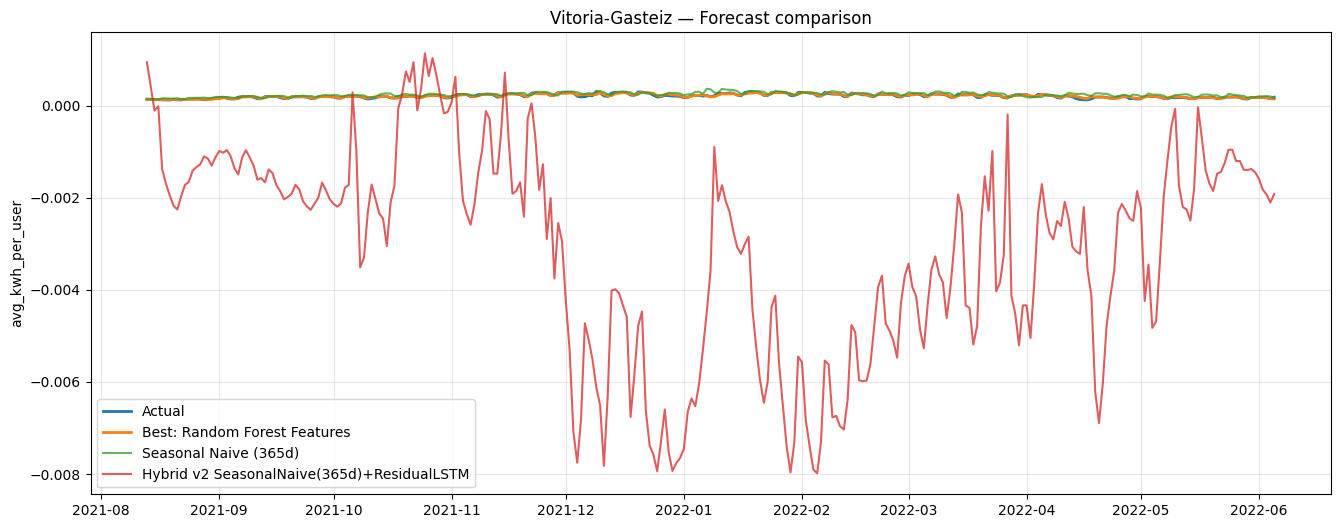

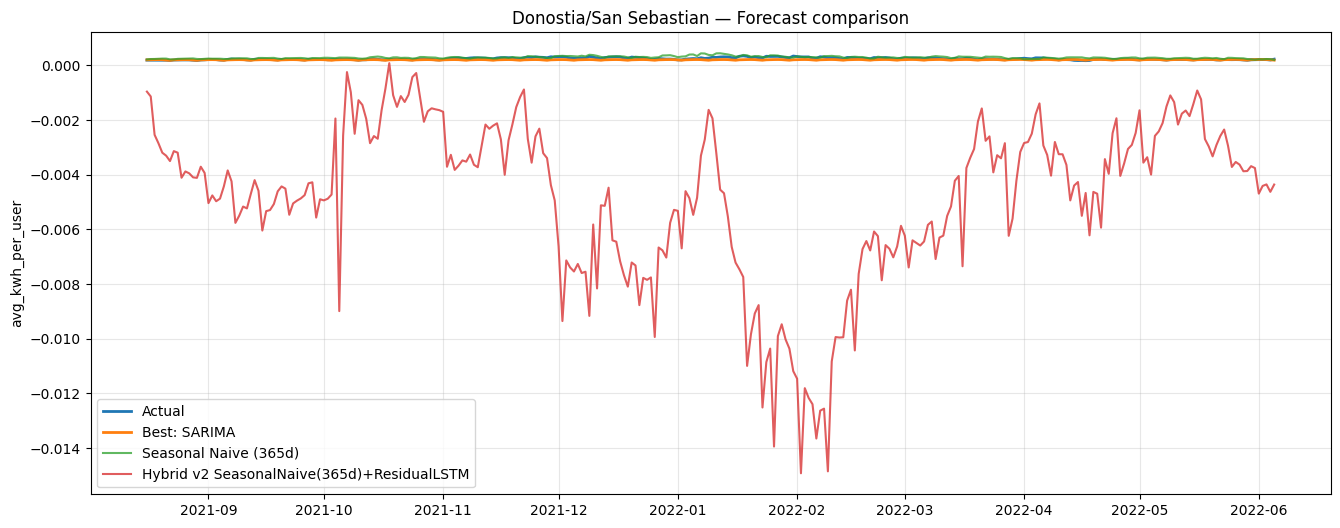

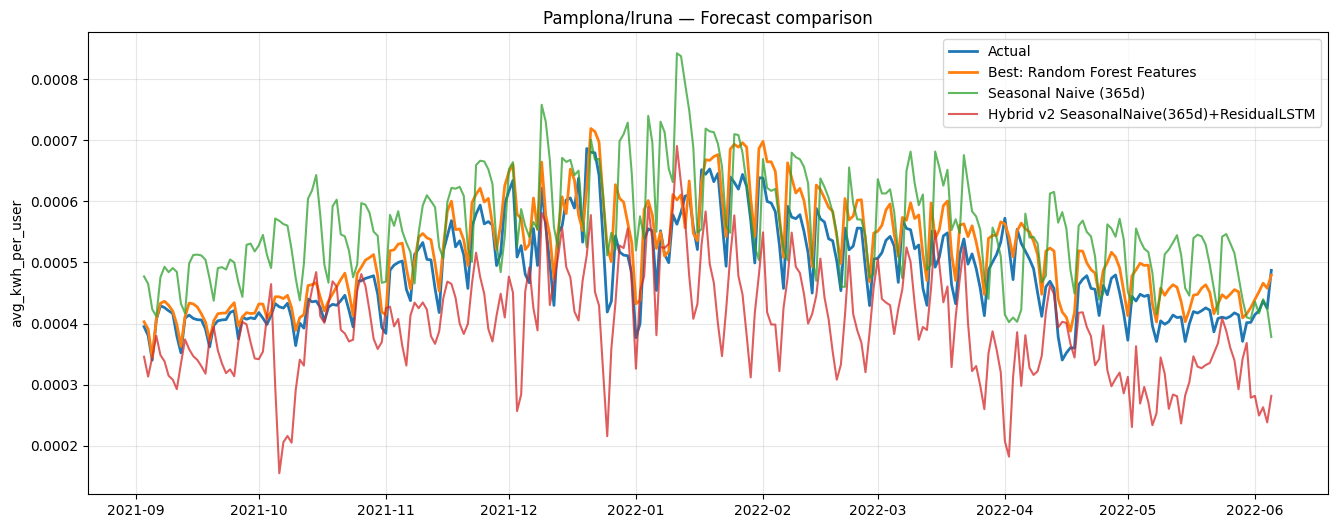

In [13]:
comparison_dfs = {}
summary_rows = []

for group in GROUPS_TO_FORECAST:
    comp = pd.DataFrame([v['metrics'] for v in all_results[group].values()]).set_index('Model').sort_values('RMSE')
    comparison_dfs[group] = comp
    print(f'\n{"="*100}\nFINAL COMPARISON — {group}\n{"="*100}')
    display(comp.round(4))

    best = comp.iloc[0]
    baseline_names = [i for i in comp.index if i == 'Naive' or i.startswith('Seasonal Naive') or i.startswith('Rolling')]
    best_baseline = comp.loc[baseline_names].sort_values('RMSE').iloc[0]
    summary_rows.append({
        GROUP_COL: group,
        'Best model': best.name,
        'Best RMSE': best['RMSE'],
        'Best baseline': best_baseline.name,
        'Baseline RMSE': best_baseline['RMSE'],
        'Improvement vs baseline (%)': (best_baseline['RMSE'] - best['RMSE']) / best_baseline['RMSE'] * 100
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))

for group in GROUPS_TO_FORECAST:
    test = series_data[group]['test'][TARGET_COL]
    best_model = comparison_dfs[group].index[0]
    plt.figure(figsize=(16, 6))
    plt.plot(test.index, test.values, label='Actual', linewidth=2)
    plt.plot(all_results[group][best_model]['pred'].index, all_results[group][best_model]['pred'].values, label=f'Best: {best_model}', linewidth=2)
    for name, data in all_results[group].items():
        if name.startswith('Seasonal Naive') or name.startswith('Hybrid'):
            plt.plot(data['pred'].index, data['pred'].values, label=name, alpha=0.75)
    plt.title(f'{group} — Forecast comparison')
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## 12. Save outputs

In [14]:
OUTPUT_DIR = BASE_PATH / f'forecasting_model_results_365_seasonality_v6_{TARGET_COL}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUTPUT_DIR / 'summary_results.csv'
summary_df.to_csv(summary_path, index=False)
print('Saved summary:', summary_path)

for group, comp in comparison_dfs.items():
    safe = str(group).replace('/', '_').replace(' ', '_')
    comp.to_csv(OUTPUT_DIR / f'{safe}_metrics.csv')
    pred_df = pd.DataFrame(index=series_data[group]['test'].index)
    pred_df['actual'] = series_data[group]['test'][TARGET_COL]
    for model_name, data in all_results[group].items():
        pred_df[model_name] = data['pred']
    pred_df.to_csv(OUTPUT_DIR / f'{safe}_predictions.csv')
print('Done. Results saved to:', OUTPUT_DIR)

Saved summary: C:\Users\GONCA\Desktop\Iscte\MCD\Theses\forecasting_model_results_365_seasonality_v6_avg_kwh_per_user\summary_results.csv
Done. Results saved to: C:\Users\GONCA\Desktop\Iscte\MCD\Theses\forecasting_model_results_365_seasonality_v6_avg_kwh_per_user


> Thesis text suggestion: The hybrid architecture decomposes the forecasting problem into a deterministic seasonal component and a non-linear residual component. The seasonal component is estimated with a seasonal naive rule, which is a strong baseline for daily electricity consumption because it directly preserves repeated demand patterns. The residual series, defined as the difference between observed consumption and the seasonal naive estimate, is then modelled using a neural network with calendar, lag, rolling, holiday, bridge-day, and municipality-normalised features. The final forecast is obtained by adding the predicted residual to the seasonal naive component.

## 13. Comparison: old target (`avg_kwh`) vs new target (`avg_kwh_per_user`)

MAPE and sMAPE are used for comparison because the two targets have different scales (MAE/RMSE are not directly comparable). Negative delta means the new target yields a better-fitting model.

In [15]:
OLD_DIR = BASE_PATH / 'forecasting_model_results_365_seasonality_avg_kwh_per_user_v3'

for group in GROUPS_TO_FORECAST:
    safe = str(group).replace('/', '_').replace(' ', '_')
    old_path = OLD_DIR / f'{safe}_metrics.csv'
    if not old_path.exists():
        print(f'[skip] old results not found for {group}: {old_path}')
        continue

    old = pd.read_csv(old_path).set_index('Model')[['MAPE(%)', 'sMAPE(%)']]
    new = comparison_dfs[group][['MAPE(%)', 'sMAPE(%)']]

    merged = old.join(new, lsuffix='_avg_kwh', rsuffix='_avg_kwh_per_user')
    merged['MAPE delta (pp)']  = merged['MAPE(%)_avg_kwh_per_user']  - merged['MAPE(%)_avg_kwh']
    merged['sMAPE delta (pp)'] = merged['sMAPE(%)_avg_kwh_per_user'] - merged['sMAPE(%)_avg_kwh']
    merged = merged.sort_values('MAPE(%)_avg_kwh_per_user')

    print(f'\n{"="*100}')
    print(f'TARGET COMPARISON — {group}')
    print(f'  negative delta = new target (avg_kwh_per_user) is BETTER')
    print(f'{"="*100}')
    display(merged.round(4))

[skip] old results not found for Vitoria-Gasteiz: C:\Users\GONCA\Desktop\Iscte\MCD\Theses\forecasting_model_results_365_seasonality_avg_kwh_per_user_v3\Vitoria-Gasteiz_metrics.csv
[skip] old results not found for Donostia/San Sebastian: C:\Users\GONCA\Desktop\Iscte\MCD\Theses\forecasting_model_results_365_seasonality_avg_kwh_per_user_v3\Donostia_San_Sebastian_metrics.csv
[skip] old results not found for Pamplona/Iruna: C:\Users\GONCA\Desktop\Iscte\MCD\Theses\forecasting_model_results_365_seasonality_avg_kwh_per_user_v3\Pamplona_Iruna_metrics.csv
